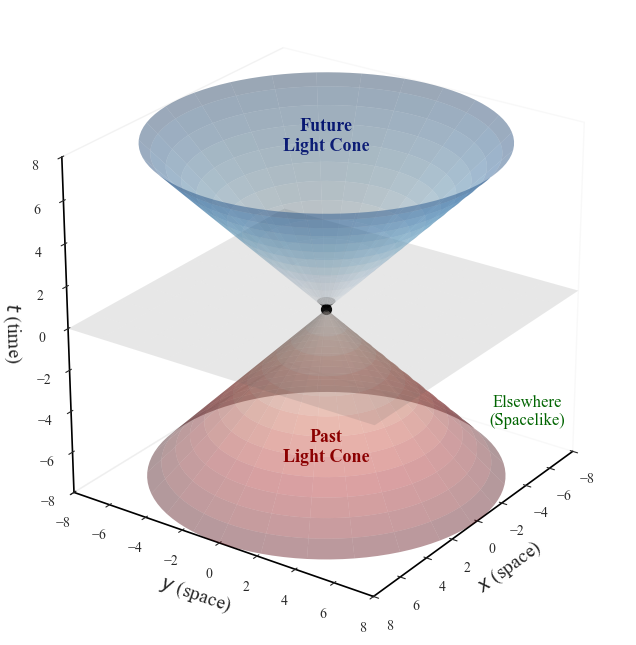

In [31]:
"""LIGHTCONE"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

# -------------------------------------------------------------------------
# FIGURE CONFIGURATION (academic / publication style)
# -------------------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 14,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "figure.titlesize": 18,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# Create figure and 3D axes
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# -------------------------------------------------------------------------
# DATA FOR LIGHT CONE
# -------------------------------------------------------------------------
t = np.linspace(-8, 8, 100)
theta = np.linspace(0, 2 * np.pi, 100)
t_grid, theta_grid = np.meshgrid(t, theta)

# Cone equation
r = np.abs(t_grid)
x = r * np.cos(theta_grid)
y = r * np.sin(theta_grid)

# Mask future/past regions
t_future = np.where(t_grid >= 0, t_grid, np.nan)
t_past = np.where(t_grid <= 0, t_grid, np.nan)

# -------------------------------------------------------------------------
# PLOT SURFACES
# -------------------------------------------------------------------------
# Future light cone (blue tone)
ax.plot_surface(
    x, y, t_future, rstride=4, cstride=4, alpha=0.4,
    facecolors=cm.Blues((t_future - np.nanmin(t_future)) / np.nanmax(t_future)),
    linewidth=0, antialiased=True
)

# Past light cone (red tone)
ax.plot_surface(
    x, y, t_past, rstride=4, cstride=4, alpha=0.4,
    facecolors=cm.Reds((np.abs(t_past) - np.nanmin(np.abs(t_past))) / np.nanmax(np.abs(t_past))),
    linewidth=0, antialiased=True
)

# Present plane (t = 0)
plane_x = np.linspace(-8, 8, 10)
plane_y = np.linspace(-8, 8, 10)
plane_xx, plane_yy = np.meshgrid(plane_x, plane_y)
plane_t = np.zeros_like(plane_xx)
ax.plot_surface(plane_xx, plane_yy, plane_t, color='gray', alpha=0.15)

# -------------------------------------------------------------------------
# LABELS & ANNOTATIONS
# -------------------------------------------------------------------------
ax.set_xlabel(r'$x$ (space)')
ax.set_ylabel(r'$y$ (space)')
ax.set_zlabel(r'$t$ (time)')

ax.text(0, 0, 7.5, 'Future\nLight Cone', color='navy', ha='center', fontsize=13, weight='bold')
ax.text(0, 0, -7.5, 'Past\nLight Cone', color='darkred', ha='center', fontsize=13, weight='bold')
ax.text(-4, 8, -5, 'Elsewhere\n(Spacelike)', color='darkgreen', ha='center', fontsize=12)

# The "present" event
ax.scatter(0, 0, 0, color='black', s=50, label='Present Event')

# -------------------------------------------------------------------------
# STYLING & VIEW
# -------------------------------------------------------------------------
ax.set_xlim([-8, 8])
ax.set_ylim([-8, 8])
ax.set_zlim([-8, 8])
ax.view_init(elev=25, azim=35)

# Clean ticks
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_box_aspect([1, 1, 1])  # Equal scale

# Minimal grid
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


# -------------------------------------------------------------------------
# SAVE FIGURE (SVG for publication)
# -------------------------------------------------------------------------
os.makedirs('Ch1', exist_ok=True)
plt.savefig('Ch1/LightCone.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


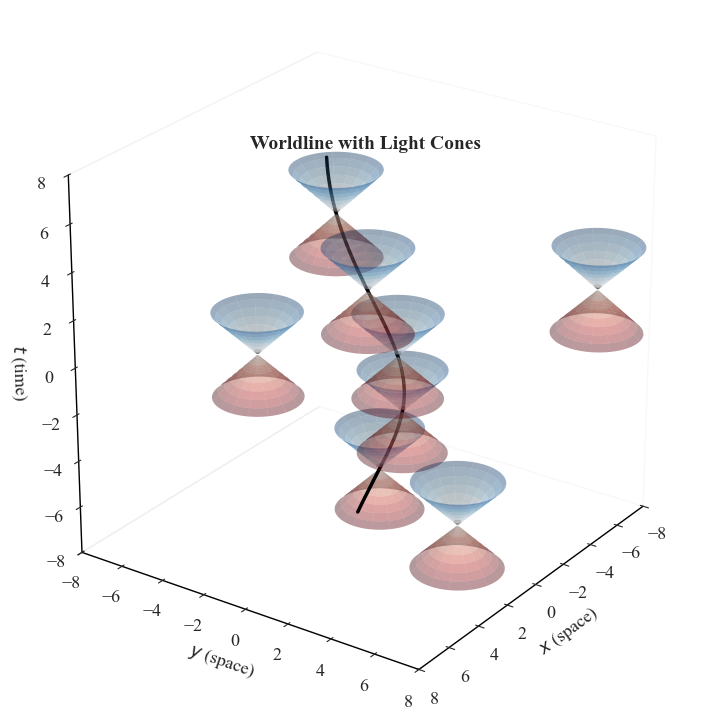

In [33]:
"""LIGHTCONE-AT-EVENT"""

import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

# ---------------------------------------------------------------
# Global plot style for academic figures
# ---------------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0
})

# ---------------------------------------------------------------
# Helper function to draw a light cone at a given spacetime point
# ---------------------------------------------------------------
def draw_light_cone(ax, center, height=2.5, resolution=60, color='gray', alpha=0.3):
    """Draw a light cone centered at (x0, y0, t0)."""
    t = np.linspace(-height, height, resolution)
    theta = np.linspace(0, 2*np.pi, resolution)
    t_grid, theta_grid = np.meshgrid(t, theta)
    r = np.abs(t_grid)

    t_future = np.where(t_grid >= 0, t_grid, np.nan)
    t_past = np.where(t_grid <= 0, t_grid, np.nan)

    x = r * np.cos(theta_grid) + center[0]
    y = r * np.sin(theta_grid) + center[1]

    z_past = t_past + center[2]
    z_future = t_future + center[2]

    ax.plot_surface(x, y, z_past, rstride=4, cstride=4, alpha=0.4,
    facecolors=cm.Reds((np.abs(t_past) - np.nanmin(np.abs(t_past))) / np.nanmax(np.abs(t_past))),
    linewidth=0, antialiased=True)

    ax.plot_surface(x, y, z_future, rstride=4, cstride=4, alpha=0.4,
    facecolors=cm.Blues((t_future - np.nanmin(t_future)) / np.nanmax(t_future)),
    linewidth=0, antialiased=True)

# ---------------------------------------------------------------
# Create figure and axes
# ---------------------------------------------------------------
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# ---------------------------------------------------------------
# Particle worldline (a smooth curve through spacetime)
# ---------------------------------------------------------------
t = np.linspace(-8, 8, 300)
x = 1.5 * np.sin(0.3 * t)
y = 1.5 * np.cos(0.3 * t)
ax.plot(x, y, t, color='black', linewidth=2.5, label='Particle Worldline')

# ---------------------------------------------------------------
# Light cones along the worldline
# ---------------------------------------------------------------
for z0 in np.linspace(-6, 6, 5):
    idx = np.argmin(np.abs(t - z0))
    center = (x[idx], y[idx], t[idx])
    draw_light_cone(ax, center, height=1.8, color='gray', alpha=0.25)

# ---------------------------------------------------------------
# A few cones "outside" the worldline to represent other events
# ---------------------------------------------------------------
external_points = [(4, 7, -4), (-4,8, 3), (3, -3, 0)]
for c in external_points:
    draw_light_cone(ax, c, height=1.8, color='lightgray', alpha=0.2)

# ---------------------------------------------------------------
# Labels and styling
# ---------------------------------------------------------------
ax.text(0, 0, 8.3, 'Worldline with Light Cones', ha='center', fontsize=14, weight='bold')

ax.set_xlabel(r'$x$ (space)')
ax.set_ylabel(r'$y$ (space)')
ax.set_zlabel(r'$t$ (time)')

ax.set_xlim([-8, 8])
ax.set_ylim([-8, 8])
ax.set_zlim([-8, 8])

ax.view_init(elev=25, azim=35)
ax.set_box_aspect([1, 1, 1])

ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# ---------------------------------------------------------------
# Save figure
# ---------------------------------------------------------------
os.makedirs('Ch1', exist_ok=True)
plt.savefig('Ch1/WorldlineCones.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_gravitational_flux():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1]) 

    # 1. Create the Arbitrary Closed Surface S (Deformed Sphere)
    u = np.linspace(0, 2 * np.pi, 40)
    v = np.linspace(0, np.pi, 40)
    U, V = np.meshgrid(u, v)
    
    # Base radius with some sinusoidal deformation for an "arbitrary" organic shape
    R = 2 + 0.2 * np.sin(3 * U) * np.cos(2 * V)
    
    X = R * np.sin(V) * np.cos(U)
    Y = R * np.sin(V) * np.sin(U)
    Z = R * np.cos(V)
    
    # Plot the surface S (translucent to see inside)
    ax.plot_surface(X, Y, Z, color='cyan', alpha=0.15, edgecolor='teal', linewidth=0.3)

    # 2. Create the Mass Density Cloud (\rho) inside Volume V
    num_particles = 300
    # Use normal distribution to cluster mass towards the center
    rho_x = np.random.normal(0, 0.4, num_particles)
    rho_y = np.random.normal(0, 0.4, num_particles)
    rho_z = np.random.normal(0, 0.4, num_particles)
    
    # Plot the particle cloud
    ax.scatter(rho_x, rho_y, rho_z, color='darkred', s=10, alpha=0.6, label='Mass Density ($\\rho$)')

    # 3. Add Vectors (dA outward, a inward)
    # Pick a few points on the surface to draw vectors
    indices = [(10, 10), (20, 25), (30, 15), (15, 35)]
    
    for i, j in indices:
        x, y, z = X[i, j], Y[i, j], Z[i, j]
        
        # Calculate normal vector (outward) - approximating as radial for simplicity
        norm = np.sqrt(x**2 + y**2 + z**2)
        nx, ny, nz = x/norm, y/norm, z/norm
        
        # Area vector dA (outward)
        ax.quiver(x, y, z, nx, ny, nz, length=0.8, color='blue', linewidth=2, arrow_length_ratio=0.3)
        ax.text(x + nx, y + ny, z + nz, r'$d\mathbf{A}$', color='blue', fontsize=12, fontweight='bold')
        
        # Acceleration vector a (inward toward mass)
        ax.quiver(x, y, z, -nx, -ny, -nz, length=0.6, color='red', linewidth=2, arrow_length_ratio=0.3)
        if i == indices[0][0]: # Just label one acceleration vector to avoid clutter
            ax.text(x - 0.8*nx, y - 0.8*ny, z - 0.8*nz, r'$\mathbf{a}$', color='red', fontsize=12, fontweight='bold')

    # 4. Add Labels for Surface S and Volume V
    ax.text(2.5, 0, 2, 'Surface $S$', fontsize=14, color='teal', fontweight='bold')
    ax.text(0.8, 0.8, 0.8, 'Volume $V$', fontsize=14, color='black', fontweight='bold')
    ax.text(0, 0, -1.5, r'Mass Density $\rho$', fontsize=14, color='darkred', fontweight='bold')

    # Cleanup axes for a cleaner diagram look
    ax.set_axis_off()
    
    # Set view angle for best visibility
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    
    # Save the figure as an SVG so you can import it cleanly into LaTeX
    plt.savefig('ch1/images/poisson_derivation_diagram.svg', format='svg', transparent=True)
    print("Saved as 'poisson_derivation_diagram.svg'")
    
    plt.show()

if __name__ == "__main__":
    plot_gravitational_flux()

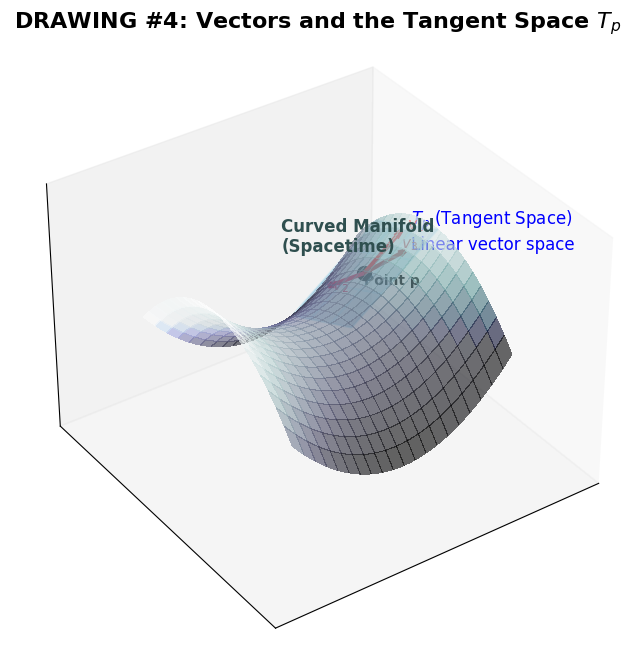

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LightSource

def generate_tangent_space_plot():
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(projection='3d')

    # --- 1. Define the Curved Manifold (Spacetime) ---
    # We'll use a saddle surface: z = 0.3 * (x^2 - y^2) for good visual curvature
    surface_range = 2
    x_range = np.linspace(-surface_range, surface_range, 100)
    y_range = np.linspace(-surface_range, surface_range, 100)
    X, Y = np.meshgrid(x_range, y_range)
    Z = 0.3 * (X**2 - Y**2)

    # Plot the surface with lighting and a wireframe to emphasize curvature
    ls = LightSource(azdeg=135, altdeg=45)
    rgb = ls.shade(Z, cmap=plt.cm.bone, vert_exag=1.0, blend_mode='overlay')
    surf = ax.plot_surface(X, Y, Z, facecolors=rgb, rstride=5, cstride=5,
                           alpha=0.6, linewidth=0, antialiased=False, shade=False)
    # ax.plot_wireframe(X, Y, Z, color='black', rstride=10, cstride=10, alpha=0.1) # Optional wireframe

    # --- 2. Define the Point 'p' ---
    # Choose a point on the surface (e.g., near the saddle point)
    p_coord = np.array([1.2, 0.7, 0.3 * (1.2**2 - 0.7**2)])
    ax.scatter([p_coord[0]], [p_coord[1]], [p_coord[2]], color='black', s=100, zorder=10, label='Point p')

    # --- 3. Compute and Define the Tangent Plane T_p ---
    # Function gradients for the surface z = 0.3(x^2 - y^2):
    # dz/dx = 0.6x, dz/dy = -0.6y
    dfdx_p = 0.6 * p_coord[0]
    dfdy_p = -0.6 * p_coord[1]

    # Define a local grid for the tangent plane around point p
    plane_size = 0.8
    plane_x_range = np.linspace(p_coord[0] - plane_size, p_coord[0] + plane_size, 30)
    plane_y_range = np.linspace(p_coord[1] - plane_size, p_coord[1] + plane_size, 30)
    Plane_X, Plane_Y = np.meshgrid(plane_x_range, plane_y_range)
    # Equation of the tangent plane: z = f(p) + (df/dx)|p * (x - x_p) + (df/dy)|p * (y - y_p)
    Plane_Z = p_coord[2] + dfdx_p * (Plane_X - p_coord[0]) + dfdy_p * (Plane_Y - p_coord[1])

    # Plot the Tangent Plane
    ax.plot_surface(Plane_X, Plane_Y, Plane_Z, color='lightskyblue', alpha=0.4, rstride=5, cstride=5, linewidth=0)
    ax.plot_wireframe(Plane_X, Plane_Y, Plane_Z, color='skyblue', rstride=10, cstride=10, alpha=0.3)

    # --- 4. Define and Draw Tangent Vectors in T_p ---
    # The basis vectors for T_p are (1, 0, dz/dx) and (0, 1, dz/dy) at p.
    # Note: Matplotlib's quiver in 3D is tricky with aspect ratios and normalization.
    # We define vectors that originate at p and lie within the plane coordinates.
    e_x = np.array([1, 0, dfdx_p])
    e_y = np.array([0, 1, dfdy_p])
    
    # Scale them for visibility
    scale_factor = 0.7
    v1 = scale_factor * e_x 
    v2 = scale_factor * (-0.4 * e_x + 0.8 * e_y) # A linear combination
    v3 = scale_factor * (0.6 * e_x - 0.7 * e_y)

    # Origin for all vectors is point p
    quiver_origins = np.tile(p_coord, (3, 1))
    # Combine the vector components
    quiver_vectors = np.stack((v1, v2, v3), axis=0)

    # Add quiver arrows for the vectors, ensuring they are zordered correctly.
    # We must use zorder carefully so they look like they are 'in' or 'on' the plane.
    # Drawing on the tangent plane with a slight offset in the viewing direction helps.
    ax.quiver(quiver_origins[:, 0], quiver_origins[:, 1], quiver_origins[:, 2],
              quiver_vectors[:, 0], quiver_vectors[:, 1], quiver_vectors[:, 2],
              color=['red', 'crimson', 'firebrick'], linewidth=3, arrow_length_ratio=0.15,
              normalize=False)

    # --- 5. Labels, Aesthetics, and Views ---
    # Label the manifold
    ax.text(-2.5, -2.5, 0.3 * (2.5**2 + 2.5**2), "Curved Manifold\n(Spacetime)", 
            color='darkslategray', fontsize=12, fontweight='bold', zorder=15)

    # Label the tangent space T_p and the point p
    ax.text(p_coord[0] + plane_size + 0.1, p_coord[1], p_coord[2] + 0.1, 
            "$T_p$ (Tangent Space)\nLinear vector space", color='blue', fontsize=12)
    ax.text(p_coord[0], p_coord[1], p_coord[2] - 0.2, "Point p", color='black', fontsize=10, fontweight='bold')
    
    # Add labels to the vectors for clarity. Position them dynamically.
    label_offset = 0.1
    ax.text(p_coord[0] + v1[0] + label_offset, p_coord[1] + v1[1], p_coord[2] + v1[2], "$v_1$", color='red', fontweight='bold', fontsize=11)
    ax.text(p_coord[0] + v2[0], p_coord[1] + v2[1] - label_offset, p_coord[2] + v2[2], "$v_2$", color='crimson', fontweight='bold', fontsize=11)
    ax.text(p_coord[0] + v3[0], p_coord[1] + v3[1] + label_offset, p_coord[2] + v3[2], "$v_3$", color='firebrick', fontweight='bold', fontsize=11)

    # Clean up axes for a geometric diagram feel
    ax.grid(False)
    ax.xaxis.set_ticklabels([])
    ax.yaxis.set_ticklabels([])
    ax.zaxis.set_ticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    # Optional: Set axis limits explicitly to create more floating space
    padding = 1.0
    ax.set_xlim(-surface_range - padding, surface_range + padding)
    ax.set_ylim(-surface_range - padding, surface_range + padding)
    ax.set_zlim(Z.min() - padding, Z.max() + padding)
    
    # Set the view angle for optimal visualization of vectors 'lying flat' in the plane
    # Elev=30, Azim=-115 usually works well to show the saddle and the plane intersection
    ax.view_init(elev=35, azim=-125) 
    # Use ax.axis('off') to hide everything except the drawing. Set title manually for a label.
    # ax.axis('off')
    
    # Set diagram overall title. The drawing itself satisfies requirements.
    ax.set_title("DRAWING #4: Vectors and the Tangent Space $T_p$", fontsize=16, fontweight='bold')
    
    # Optional: Save the figure. For use in LaTeX, uncomment the next line and pick a format.
    plt.savefig('ch1/images/tangent_space_vectors.pdf', format='pdf', bbox_inches='tight') # Better for LaTeX    
    plt.show()

# Run the function to generate and show the plot
if __name__ == "__main__":
    generate_tangent_space_plot()

<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\P'
<>:73: SyntaxWarning: invalid escape sequence '\P'
<>:74: SyntaxWarning: invalid escape sequence '\P'
<>:32: SyntaxWarning: invalid escape sequence '\d'
<>:33: SyntaxWarning: invalid escape sequence '\d'
<>:46: SyntaxWarning: invalid escape sequence '\d'
<>:48: SyntaxWarning: invalid escape sequence '\d'
<>:68: SyntaxWarning: invalid escape sequence '\P'
<>:73: SyntaxWarning: invalid escape sequence '\P'
<>:74: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Abdul\AppData\Local\Temp\ipykernel_1112\2016669704.py:32: SyntaxWarning: invalid escape sequence '\d'
  ax1.plot(t, q_var, 'r--', label='Varied path: $q(t) + \delta q(t)$')
C:\Users\Abdul\AppData\Local\Temp\ipykernel_1112\2016669704.py:33: SyntaxWarning: invalid escape sequenc

Diagram successfully saved to: ch1\images\mechanics_vs_field_theory.pdf


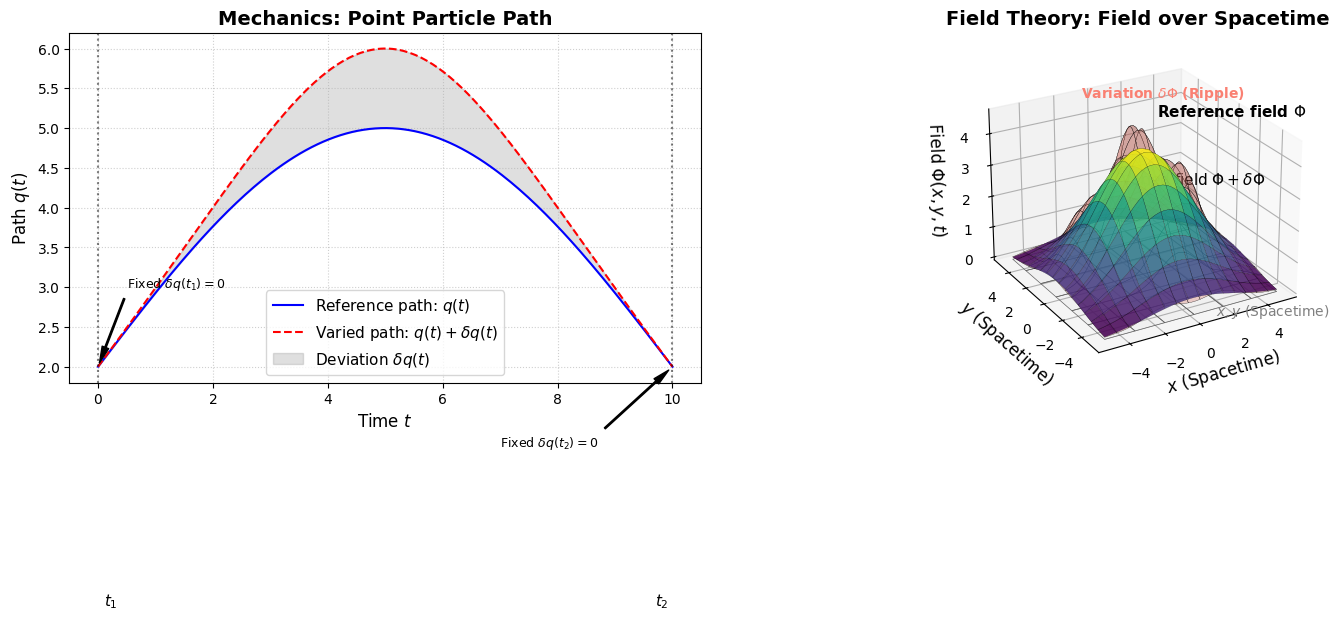

In [9]:
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def plot_mechanics_vs_field():
    # --- Data Generation for Panel 1: Classical Mechanics ---
    t = np.linspace(0, 10, 200)
    q_ref = 3 * np.sin(np.pi * t / 10) + 2
    dq = 1.0 * np.sin(np.pi * t / 10) * np.exp(-0.1 * (t - 5)**2)
    q_var = q_ref + dq

    # --- Data Generation for Panel 2: Classical Field Theory ---
    x_grid = np.linspace(-5, 5, 60)
    y_grid = np.linspace(-5, 5, 60)
    X, Y = np.meshgrid(x_grid, y_grid)
    
    Phi_ref = 4 * np.exp(-0.08 * (X**2 + Y**2))
    dPhi = 1.0 * np.exp(-0.08 * (X**2 + Y**2)) * np.cos(1.5 * X) * np.sin(1.5 * Y)
    Phi_var = Phi_ref + dPhi

    # --- Create Figure with GridSpec for Custom Proportions ---
    fig = plt.figure(figsize=(16, 8))
    # Set the width ratio: 1 for left plot, 1.4 for right plot (making it larger)
    gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.4]) 

    # --- Plot Panel 1: Mechanics ---
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(t, q_ref, 'b-', label='Reference path: $q(t)$')
    ax1.plot(t, q_var, 'r--', label='Varied path: $q(t) + \delta q(t)$')
    ax1.fill_between(t, q_ref, q_var, color='gray', alpha=0.25, label='Deviation $\delta q(t)$')

    ax1.set_xlabel('Time $t$', fontsize=12)
    ax1.set_ylabel('Path $q(t)$', fontsize=12)
    ax1.set_title('Mechanics: Point Particle Path', fontsize=14, fontweight='bold')
    ax1.legend(loc='best', fontsize=11)
    ax1.grid(True, linestyle=':', alpha=0.6)

    endpoint_times = [0, 10]
    for et in endpoint_times:
        ax1.axvline(x=et, color='k', linestyle=':', alpha=0.5)
    ax1.text(0.1, -1.0, '$t_1$', fontsize=11, color='k', fontweight='bold')
    ax1.text(9.7, -1.0, '$t_2$', fontsize=11, color='k', fontweight='bold')
    ax1.annotate('Fixed $\delta q(t_1)=0$', xy=(0, q_ref[0]), xytext=(0.5, q_ref[0]+1), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=9)
    ax1.annotate('Fixed $\delta q(t_2)=0$', xy=(10, q_ref[-1]), xytext=(7.0, q_ref[-1]-1), 
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5), fontsize=9)

    # --- Plot Panel 2: Field Theory ---
    ax2 = fig.add_subplot(gs[1], projection='3d')

    floor_grid_spacing = 10
    ax2.plot_surface(X, Y, np.zeros_like(X), color='lightgray', alpha=0.05, rstride=floor_grid_spacing, cstride=floor_grid_spacing, linewidth=0.5, edgecolors='gray')
    ax2.plot(x_grid, np.full_like(x_grid, -5), np.zeros_like(x_grid), 'k-', lw=0.5, alpha=0.2)
    ax2.plot(np.full_like(y_grid, 5), y_grid, np.zeros_like(y_grid), 'k-', lw=0.5, alpha=0.2)
    ax2.text(2, -4, -0.6, "$x, y$ (Spacetime)", color='gray', fontsize=10) 

    surf_ref = ax2.plot_surface(X, Y, Phi_ref, cmap=cm.viridis,
                                 linewidth=0.1, edgecolors='k', antialiased=True, alpha=0.85, rstride=4, cstride=4)

    surf_var = ax2.plot_surface(X, Y, Phi_var, color='salmon', 
                                 linewidth=0.2, edgecolors='k', antialiased=True, alpha=0.3, rstride=4, cstride=4)

    ax2.set_xlabel('$x$ (Spacetime)', fontsize=12)
    ax2.set_ylabel('$y$ (Spacetime)', fontsize=12)
    ax2.set_zlabel('Field $\Phi(x, y, t)$', fontsize=12)
    ax2.set_title('Field Theory: Field over Spacetime', fontsize=14, fontweight='bold')

    ax2.view_init(elev=25, azim=-120) 

    ax2.text(2, 2, Phi_ref.max()*1.1, "Reference field $\Phi$", color='black', fontweight='bold', fontsize=11)
    ax2.text(-3, -3, Phi_var.max()*0.85, "Varied field $\Phi + \delta \Phi$", color='k', fontsize=11)
    ax2.text(0, -2, 6, r'Variation $\delta \Phi$ (Ripple)', color='salmon', fontweight='bold', fontsize=10, ha='center')

    # --- File Saving Logic ---
    plt.tight_layout()
    
    # Define the directory path
    save_dir = os.path.join("ch1", "images")
    
    # Create the directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)
    
    # Define full file path
    # Changing the extension below to .svg will save as SVG instead. PDF is standard for LaTeX.
    file_path = os.path.join(save_dir, "mechanics_vs_field_theory.pdf")
    
    # Save the figure
    plt.savefig(file_path, format='pdf', bbox_inches='tight')
    print(f"Diagram successfully saved to: {file_path}")

    # Display plot
    plt.show()

if __name__ == "__main__":
    plot_mechanics_vs_field()